[nltk_data] Downloading package stopwords to C:\Users\Raj
[nltk_data]     Coach\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Raj
[nltk_data]     Coach\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Raj
[nltk_data]     Coach\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Original Dataset Shape: (568454, 10)

First 5 Rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I 

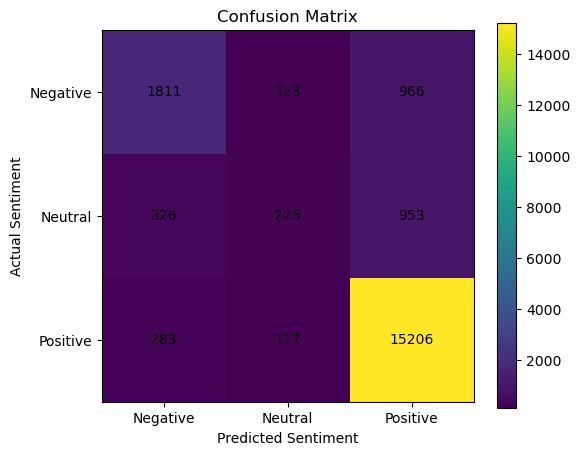

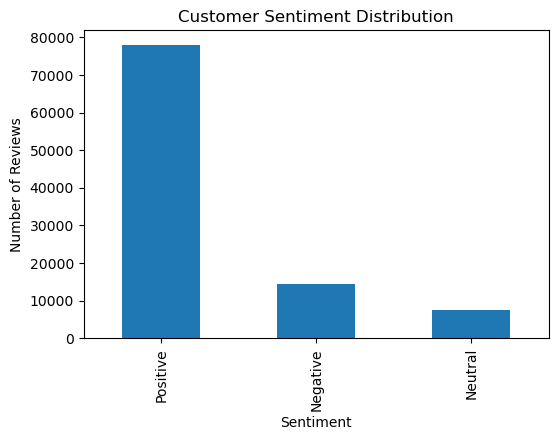


NEW REVIEW PREDICTIONS

Review: This product is amazing and I really love it
Predicted Sentiment: Positive
Confidence: 99.43 %

Review: Very bad product. It stopped working after two days
Predicted Sentiment: Positive
Confidence: 37.89 %

Review: The product is okay. Nothing special
Predicted Sentiment: Neutral
Confidence: 66.03 %

CUSTOMER REVIEW PREDICTION


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


df = pd.read_csv("Reviews.csv")

print("Original Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

df = df[['Text', 'Score']]


df.dropna(inplace=True)


df.drop_duplicates(subset='Text', inplace=True)

print("\nDataset Shape After Cleaning:", df.shape)


def sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiment'] = df['Score'].apply(sentiment)

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())

df = df.sample(
    n=min(100000, len(df)),
    random_state=42
)

print("\nDataset Used for Training:", df.shape)



stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Tokenization
    words = text.split()

    # Remove stopwords and perform lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)


print("\nCleaning Reviews...")

df['Clean_Text'] = df['Text'].apply(clean_text)

print("\nOriginal vs Cleaned Review:")
print(df[['Text', 'Clean_Text']].head())

df = df[df['Clean_Text'].str.strip() != '']

print("\nCreating TF-IDF Features...")

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['Clean_Text'])
y = df['Sentiment']

print("TF-IDF Shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

print("\nTraining Model...")

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.xticks(
    range(len(model.classes_)),
    model.classes_
)

plt.yticks(
    range(len(model.classes_)),
    model.classes_
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.show()

plt.figure(figsize=(6, 4))

df['Sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

def predict_review(review):

    # Clean the new review
    cleaned_review = clean_text(review)

    # Convert text into TF-IDF
    review_vector = vectorizer.transform(
        [cleaned_review]
    )

    # Predict sentiment
    prediction = model.predict(
        review_vector
    )

    # Get prediction probability
    probability = model.predict_proba(
        review_vector
    )

    confidence = np.max(probability) * 100

    return prediction[0], confidence


print("\n==============================")
print("NEW REVIEW PREDICTIONS")
print("==============================")

reviews = [
    "This product is amazing and I really love it",
    "Very bad product. It stopped working after two days",
    "The product is okay. Nothing special"
]

for review in reviews:

    prediction, confidence = predict_review(review)

    print("\nReview:", review)
    print("Predicted Sentiment:", prediction)
    print("Confidence:", round(confidence, 2), "%")

print("\n==============================")
print("CUSTOMER REVIEW PREDICTION")
print("==============================")

user_review = input("Enter a customer review: ")

prediction, confidence = predict_review(user_review)

print("\nReview:", user_review)
print("Predicted Sentiment:", prediction)
print("Confidence:", round(confidence, 2), "%")
